# Análisis Exploratorio de Datos (EDA)
## Dataset: `bnf.src_venta_ticket_mensual pseudonimizado`

**Objetivo:** Entender el comportamiento del dataset de venta de tickets mensuales de BNF, identificando patrones de consumo por cartera, evolución temporal, distribución de montos, comportamiento de afiliados y calidad de los datos.

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [2]:
FILE_PATH = 'bnf.src_venta_ticket_mensual pseudonimizado.csv'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    encoding='utf-8',
    low_memory=False,
    dtype={
        'PERIODO'     : 'Int64',
        'TOTAL'       : 'Int64',
        'TIPO_CARTERA': 'Int64',
        'FEC_TRANSAC' : str,
        'FECHA_PAGO'  : str,
    }
)

# Parsear fechas desde formato YYYYMMDD
df['FEC_TRANSAC'] = pd.to_datetime(df['FEC_TRANSAC'], format='%Y%m%d', errors='coerce')
df['FECHA_PAGO']  = pd.to_datetime(df['FECHA_PAGO'],  format='%Y%m%d', errors='coerce')

# Columna de período como fecha
df['FECHA_PERIODO'] = pd.to_datetime(df['PERIODO'].astype(str), format='%Y%m', errors='coerce')

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    171,933
  Columnas: 8


## 3. Vista General del Dataset

In [3]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,PERIODO,TOTAL,TIPO_CARTERA,NTIPO_CARTERA,FEC_TRANSAC,FECHA_PAGO,ID_AFI,FECHA_PERIODO
0,202505,2500,129,Cineplanet Mayo 2025,2025-05-29,2025-05-29,AFI_00464299,2025-05-01
1,202505,2500,129,Cineplanet Mayo 2025,2025-05-29,2025-05-29,AFI_00244777,2025-05-01
2,202505,2500,129,Cineplanet Mayo 2025,2025-05-29,2025-05-29,AFI_00544051,2025-05-01
3,202505,2500,129,Cineplanet Mayo 2025,2025-05-29,2025-05-29,AFI_00544051,2025-05-01
4,202505,2500,129,Cineplanet Mayo 2025,2025-05-29,2025-05-29,AFI_00544051,2025-05-01


In [4]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,PERIODO,TOTAL,TIPO_CARTERA,NTIPO_CARTERA,FEC_TRANSAC,FECHA_PAGO,ID_AFI,FECHA_PERIODO
171928,202602,11990,141,Fantasilandia Diciembre 2025,2026-02-01,2026-02-01,AFI_00853923,2026-02-01
171929,202602,11990,141,Fantasilandia Diciembre 2025,2026-02-01,2026-02-01,AFI_01059884,2026-02-01
171930,202602,9000,136,Buin Zoo Agosto 2025,2026-02-01,2026-02-01,AFI_00522348,2026-02-01
171931,202602,9000,136,Buin Zoo Agosto 2025,2026-02-01,2026-02-01,AFI_00522348,2026-02-01
171932,202602,9000,136,Buin Zoo Agosto 2025,2026-02-01,2026-02-01,AFI_00522348,2026-02-01


In [5]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 171933 entries, 0 to 171932
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   PERIODO        171933 non-null  Int64         
 1   TOTAL          171933 non-null  Int64         
 2   TIPO_CARTERA   171933 non-null  Int64         
 3   NTIPO_CARTERA  171933 non-null  str           
 4   FEC_TRANSAC    171933 non-null  datetime64[us]
 5   FECHA_PAGO     171933 non-null  datetime64[us]
 6   ID_AFI         171933 non-null  str           
 7   FECHA_PERIODO  171933 non-null  datetime64[us]
dtypes: Int64(3), datetime64[us](3), str(2)
memory usage: 11.0 MB


In [6]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
col_fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')
print(f'Columnas de fechas   ({len(col_fechas)}): {col_fechas}')

Columnas numéricas   (3): ['PERIODO', 'TOTAL', 'TIPO_CARTERA']
Columnas categóricas (2): ['NTIPO_CARTERA', 'ID_AFI']
Columnas de fechas   (3): ['FEC_TRANSAC', 'FECHA_PAGO', 'FECHA_PERIODO']


## 4. Análisis de Valores Nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos'         : df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(4)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos)
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
PERIODO,0,0.0000
TOTAL,0,0.0000
TIPO_CARTERA,0,0.0000
NTIPO_CARTERA,0,0.0000
FEC_TRANSAC,0,0.0000
FECHA_PAGO,0,0.0000
ID_AFI,0,0.0000
FECHA_PERIODO,0,0.0000



Columnas sin valores nulos: 8 de 8


In [8]:
if nulos['Nulos'].sum() > 0:
    cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()
    fig, ax = plt.subplots(figsize=(10, max(4, len(cols_con_nulos) * 0.6)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='5%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

No hay valores nulos en el dataset.


## 5. Estadísticas Descriptivas

In [9]:
print('=== Variables Numéricas — Estadísticas Descriptivas ===')
df[col_numericas].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas — Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
PERIODO,171933.000000,202438.952743,88.287854,202212.000000,202405.000000,202412.000000,202506.000000,202603.000000
TOTAL,171933.000000,4623.136861,3165.893669,100.000000,2500.000000,3000.000000,5000.000000,11990.000000
TIPO_CARTERA,171933.000000,115.454107,14.395242,100.000000,102.000000,110.000000,128.000000,147.000000


In [10]:
# Asimetría, curtosis, ceros y negativos
stats_extra = pd.DataFrame({
    'Skewness' : df[col_numericas].skew(),
    'Kurtosis' : df[col_numericas].kurt(),
    'Ceros'    : (df[col_numericas] == 0).sum(),
    'Negativos': (df[col_numericas] < 0).sum()
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,Negativos
PERIODO,-0.0514,-0.8074,0,0
TOTAL,1.3187,0.1097,0,0
TIPO_CARTERA,0.4812,-1.1734,0,0


## 6. Análisis de Variables Categóricas

In [11]:
print('=== Cardinalidad de Variables Categóricas ===')
cardinalidad = pd.DataFrame({
    'Valores únicos'     : df[col_categoricas].nunique(),
    'Valor más frecuente': [df[c].mode()[0] if not df[c].mode().empty else 'N/A' for c in col_categoricas],
    'Frecuencia moda'    : [df[c].value_counts().iloc[0] if not df[c].value_counts().empty else 0 for c in col_categoricas],
    '% Moda'             : [(df[c].value_counts().iloc[0] / len(df) * 100).round(2) if not df[c].value_counts().empty else 0 for c in col_categoricas]
}).sort_values('Valores únicos', ascending=False)
display(cardinalidad)

=== Cardinalidad de Variables Categóricas ===


,Valores únicos,Valor más frecuente,Frecuencia moda,% Moda
ID_AFI,27474,AFI_00564721,112,0.0700
NTIPO_CARTERA,33,CINEPLANET,21152,12.3000


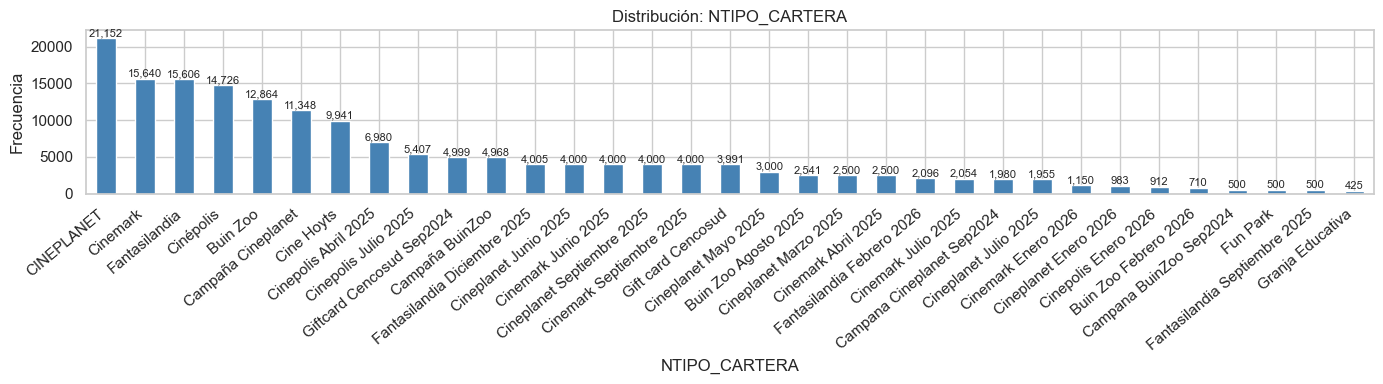

In [12]:
# Distribución de frecuencias para variables categóricas de baja cardinalidad
cat_baja_card = [c for c in col_categoricas if df[c].nunique() <= 40]

for col in cat_baja_card:
    vc = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(14, 4))
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontsize=12)
    ax.set_ylabel('Frecuencia')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

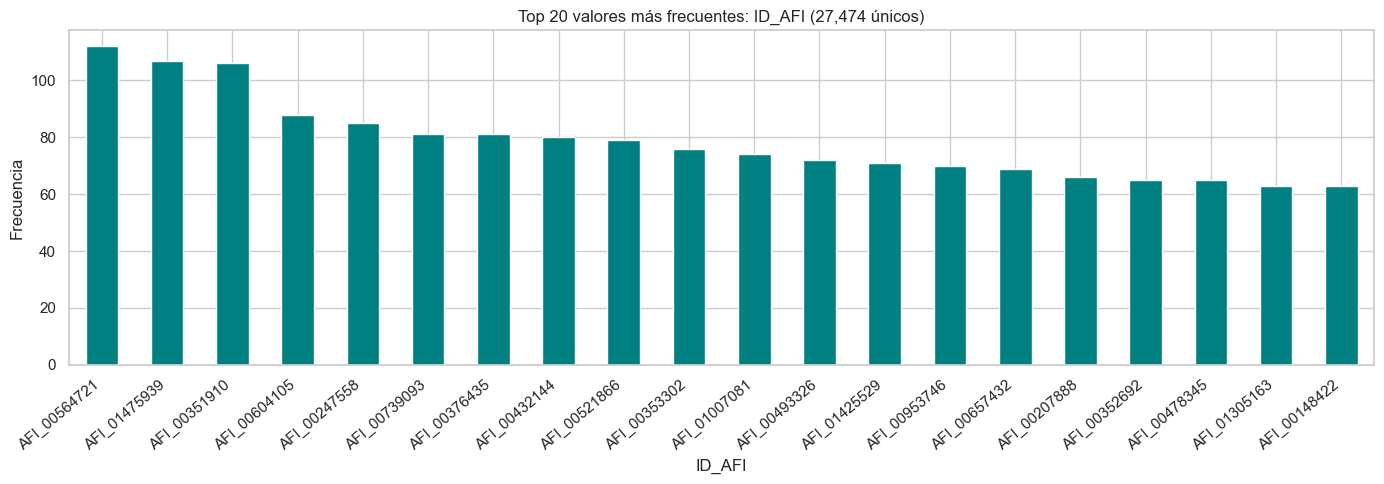

In [13]:
# Top 20 para variables de alta cardinalidad (ID_AFI)
cat_alta_card = [c for c in col_categoricas if df[c].nunique() > 40]

for col in cat_alta_card:
    fig, ax = plt.subplots(figsize=(14, 5))
    df[col].value_counts().head(20).plot(kind='bar', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Top 20 valores más frecuentes: {col} ({df[col].nunique():,} únicos)', fontsize=12)
    ax.set_ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Análisis de la Variable TOTAL (Monto del Ticket)

In [14]:
# Distribución de valores únicos del monto TOTAL
print('=== Valores únicos de TOTAL ===')
total_vc = df['TOTAL'].value_counts().sort_index()
display(total_vc.rename('Frecuencia').to_frame().assign(
    Porcentaje=(total_vc / len(df) * 100).round(2)
))

=== Valores únicos de TOTAL ===


,Frecuencia,Porcentaje
TOTAL,,
100,8,0.0000
1800,1980,1.1500
2000,4968,2.8900
2250,3596,2.0900
2500,34400,20.0100
2700,10938,6.3600
3000,49783,28.9500
3200,4000,2.3300
3300,7204,4.1900


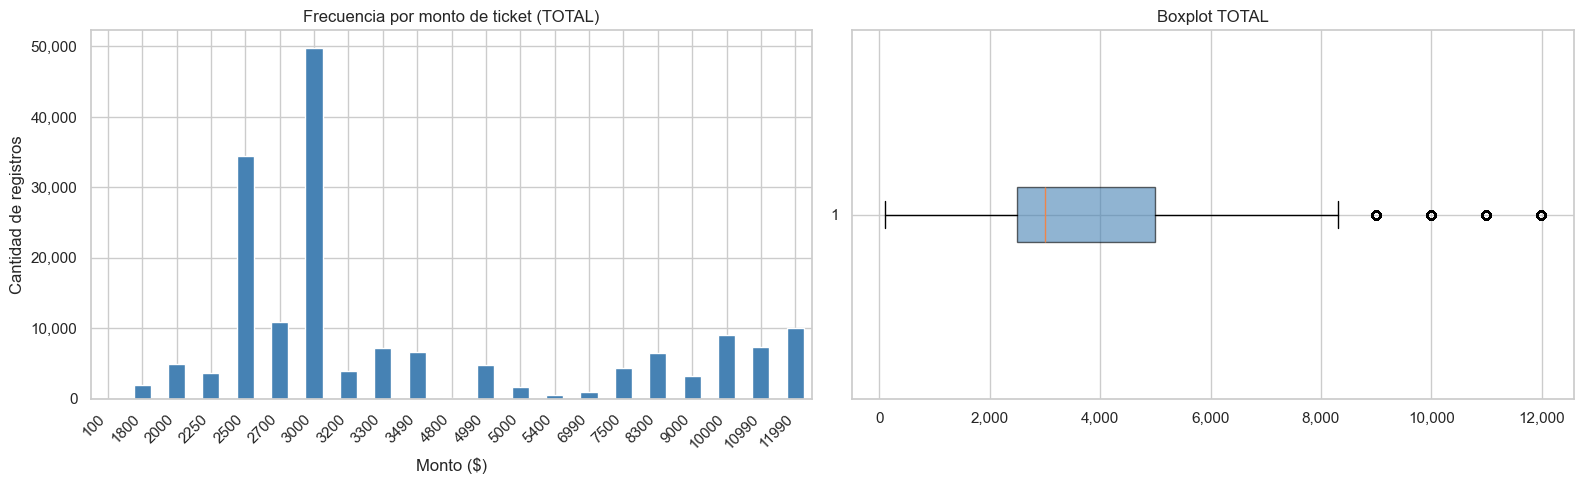


Estadísticas de TOTAL:
count   171,933.0000
mean      4,623.1369
std       3,165.8937
min         100.0000
25%       2,500.0000
50%       3,000.0000
75%       5,000.0000
max      11,990.0000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot por valor de ticket
total_vc.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Frecuencia por monto de ticket (TOTAL)', fontsize=12)
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Cantidad de registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.sca(axes[0]); plt.xticks(rotation=45, ha='right')

# Boxplot
axes[1].boxplot(df['TOTAL'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot TOTAL')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f'\nEstadísticas de TOTAL:')
print(df['TOTAL'].describe().to_string())

,TOTAL,Registros,Recaudacion_Total
6,3000,"49,783","149,349,000"
20,11990,"10,097","121,063,030"
18,10000,"8,990","89,900,000"
4,2500,"34,400","86,000,000"
19,10990,"7,320","80,446,800"
16,8300,"6,486","53,833,800"
15,7500,"4,365","32,737,500"
5,2700,"10,938","29,532,600"
17,9000,"3,251","29,259,000"
11,4990,"4,790","23,902,100"


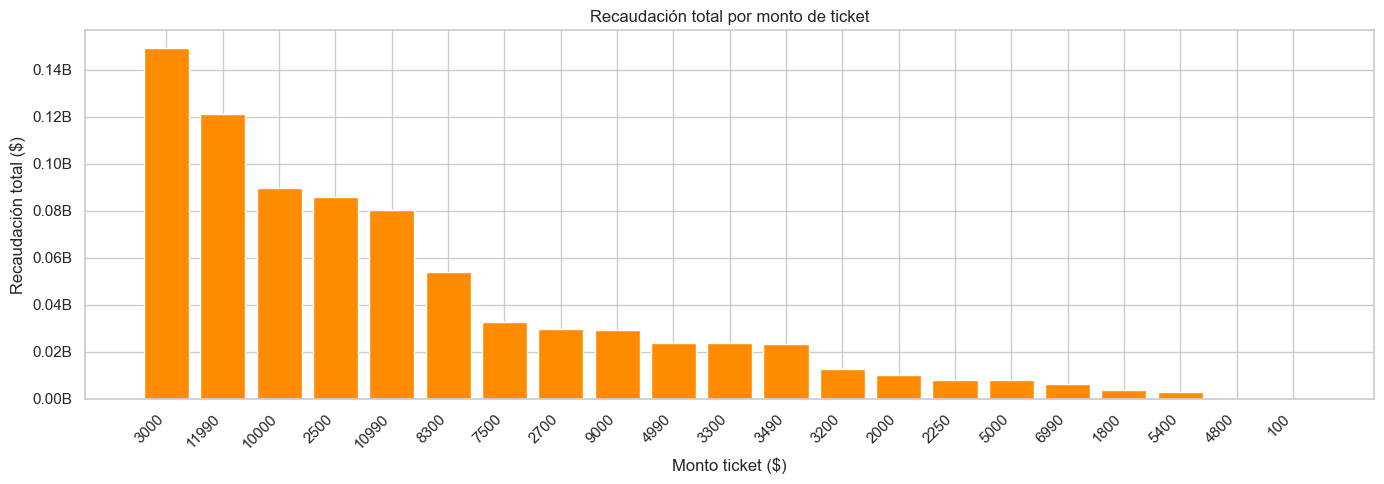

In [16]:
# Monto total recaudado agrupado por valor de ticket
monto_por_total = df.groupby('TOTAL').agg(
    Registros        =('TOTAL', 'count'),
    Recaudacion_Total=('TOTAL', 'sum')
).reset_index().sort_values('Recaudacion_Total', ascending=False)

display(monto_por_total.style.format({'Registros': '{:,}', 'Recaudacion_Total': '{:,}'}))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monto_por_total['TOTAL'].astype(str), monto_por_total['Recaudacion_Total'],
       color='darkorange', edgecolor='white')
ax.set_title('Recaudación total por monto de ticket', fontsize=12)
ax.set_xlabel('Monto ticket ($)')
ax.set_ylabel('Recaudación total ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Análisis de Carteras (NTIPO_CARTERA / TIPO_CARTERA)

In [17]:
# Resumen por cartera
resumen_cartera = df.groupby(['TIPO_CARTERA', 'NTIPO_CARTERA']).agg(
    Registros        =('TOTAL', 'count'),
    Recaudacion_Total=('TOTAL', 'sum'),
    Ticket_Promedio  =('TOTAL', 'mean'),
    Afiliados_Unicos =('ID_AFI', 'nunique')
).reset_index().sort_values('Recaudacion_Total', ascending=False)

print('=== Resumen por cartera (ordenado por recaudación) ===')
display(resumen_cartera.style.format({
    'Registros'        : '{:,}',
    'Recaudacion_Total': '{:,}',
    'Ticket_Promedio'  : '{:,.2f}',
    'Afiliados_Unicos' : '{:,}'
}))

=== Resumen por cartera (ordenado por recaudación) ===


,TIPO_CARTERA,NTIPO_CARTERA,Registros,Recaudacion_Total,Ticket_Promedio,Afiliados_Unicos
1,101,Buin Zoo,"12,864","97,430,310","7,573.87","3,773"
13,121,Fantasilandia,"10,448","86,083,520","8,239.23","3,108"
0,100,CINEPLANET,"21,152","51,971,400","2,457.04","4,205"
11,119,Giftcard Cencosud Sep2024,"4,999","49,990,000","10,000.00","2,362"
29,141,Fantasilandia Diciembre 2025,"4,005","48,019,950","11,990.00","1,366"
15,125,Fantasilandia,"3,996","47,912,040","11,990.00","1,260"
5,104,Cinemark,"15,640","46,920,000","3,000.00","3,864"
3,102,Cinépolis,"14,726","44,178,000","3,000.00","3,660"
8,115,Gift card Cencosud,"3,991","39,910,000","10,000.00","1,866"
2,102,Cine Hoyts,"9,941","29,811,400","2,998.83","2,459"


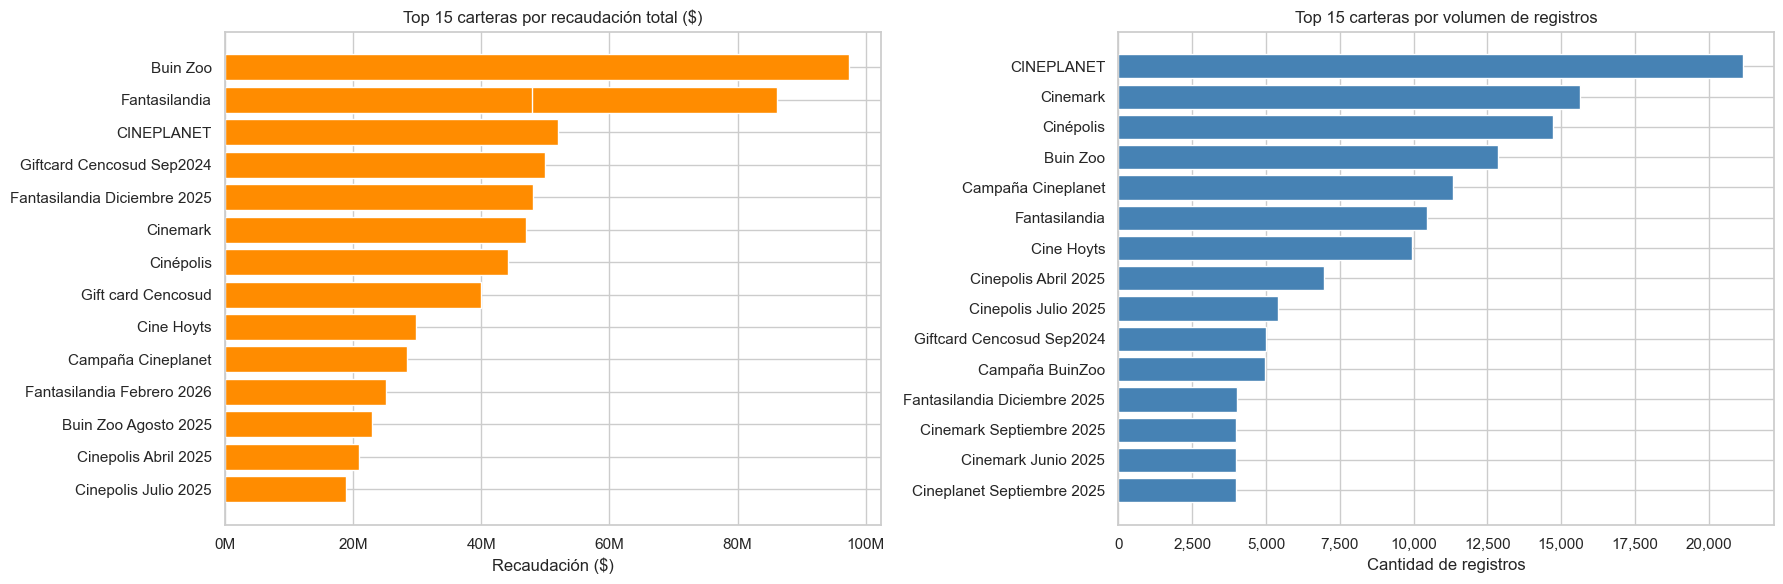

In [18]:
# Top carteras por recaudación y por volumen
top_n = 15
top_recaudacion = resumen_cartera.nlargest(top_n, 'Recaudacion_Total')
top_registros   = resumen_cartera.nlargest(top_n, 'Registros')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_recaudacion['NTIPO_CARTERA'], top_recaudacion['Recaudacion_Total'],
             color='darkorange', edgecolor='white')
axes[0].set_title(f'Top {top_n} carteras por recaudación total ($)', fontsize=12)
axes[0].set_xlabel('Recaudación ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))
axes[0].invert_yaxis()

axes[1].barh(top_registros['NTIPO_CARTERA'], top_registros['Registros'],
             color='steelblue', edgecolor='white')
axes[1].set_title(f'Top {top_n} carteras por volumen de registros', fontsize=12)
axes[1].set_xlabel('Cantidad de registros')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

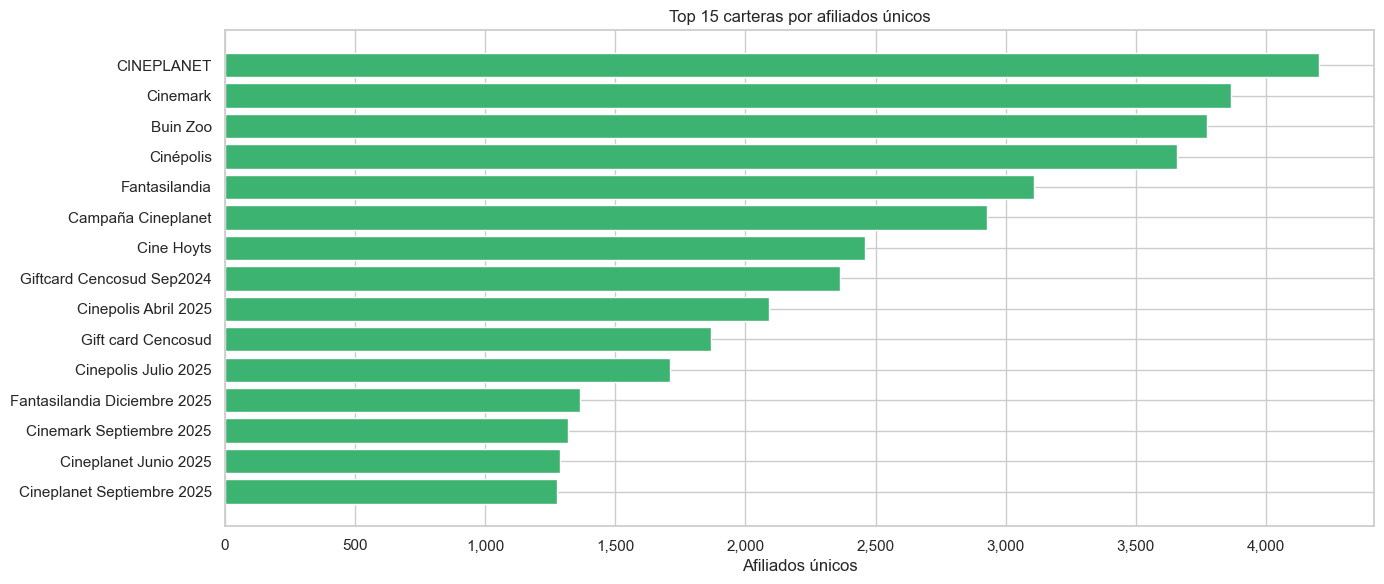

In [19]:
# Afiliados únicos por cartera (top 15)
top_afi_cartera = resumen_cartera.nlargest(top_n, 'Afiliados_Unicos')

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top_afi_cartera['NTIPO_CARTERA'], top_afi_cartera['Afiliados_Unicos'],
        color='mediumseagreen', edgecolor='white')
ax.set_title(f'Top {top_n} carteras por afiliados únicos', fontsize=12)
ax.set_xlabel('Afiliados únicos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Análisis Temporal

In [20]:
# Cobertura temporal
for col_fecha in ['FEC_TRANSAC', 'FECHA_PAGO']:
    if col_fecha in df.columns:
        print(f'{col_fecha}:')
        print(f'  Mínimo : {df[col_fecha].min()}')
        print(f'  Máximo : {df[col_fecha].max()}')
        print(f'  Rango  : {(df[col_fecha].max() - df[col_fecha].min()).days} días')
        print()

print(f'PERIODO:')
print(f'  Mínimo         : {df["PERIODO"].min()}')
print(f'  Máximo         : {df["PERIODO"].max()}')
print(f'  Períodos únicos: {df["PERIODO"].nunique()}')

FEC_TRANSAC:
  Mínimo : 2022-12-10 00:00:00
  Máximo : 2026-03-02 00:00:00
  Rango  : 1178 días

FECHA_PAGO:
  Mínimo : 2022-12-10 00:00:00
  Máximo : 2026-03-02 00:00:00
  Rango  : 1178 días

PERIODO:
  Mínimo         : 202212
  Máximo         : 202603
  Períodos únicos: 39


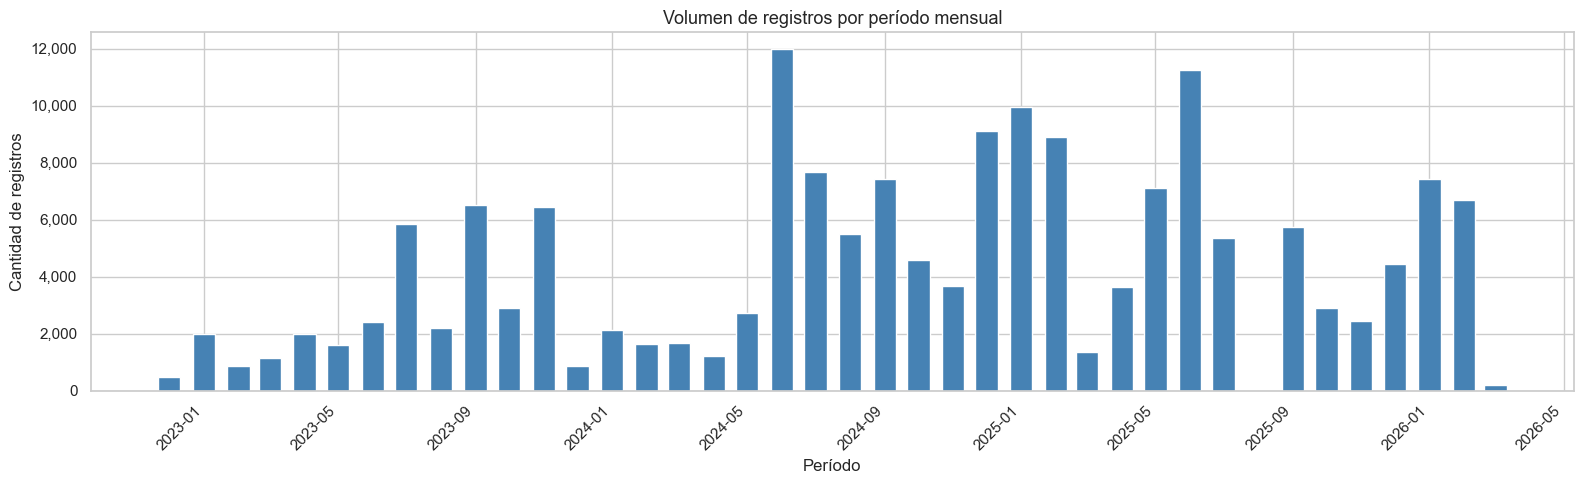

FECHA_PERIODO  Registros
   2022-12-01        465
   2023-01-01       1997
   2023-02-01        870
   2023-03-01       1146
   2023-04-01       1980
   2023-05-01       1606
   2023-06-01       2407
   2023-07-01       5843
   2023-08-01       2193
   2023-09-01       6516
   2023-10-01       2904
   2023-11-01       6444
   2023-12-01        879
   2024-01-01       2136
   2024-02-01       1623
   2024-03-01       1664
   2024-04-01       1223
   2024-05-01       2735
   2024-06-01      11969
   2024-07-01       7656
   2024-08-01       5508
   2024-09-01       7417
   2024-10-01       4583
   2024-11-01       3665
   2024-12-01       9109
   2025-01-01       9965
   2025-02-01       8901
   2025-03-01       1365
   2025-04-01       3622
   2025-05-01       7108
   2025-06-01      11262
   2025-07-01       5357
   2025-09-01       5757
   2025-10-01       2897
   2025-11-01       2429
   2025-12-01       4444
   2026-01-01       7421
   2026-02-01       6676
   2026-03-01        191


In [21]:
# Volumen de registros mensual
vol_mensual = df.groupby('FECHA_PERIODO').size().reset_index(name='Registros')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(vol_mensual['FECHA_PERIODO'], vol_mensual['Registros'], color='steelblue', width=20)
ax.set_title('Volumen de registros por período mensual', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Cantidad de registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(vol_mensual.sort_values('FECHA_PERIODO').to_string(index=False))

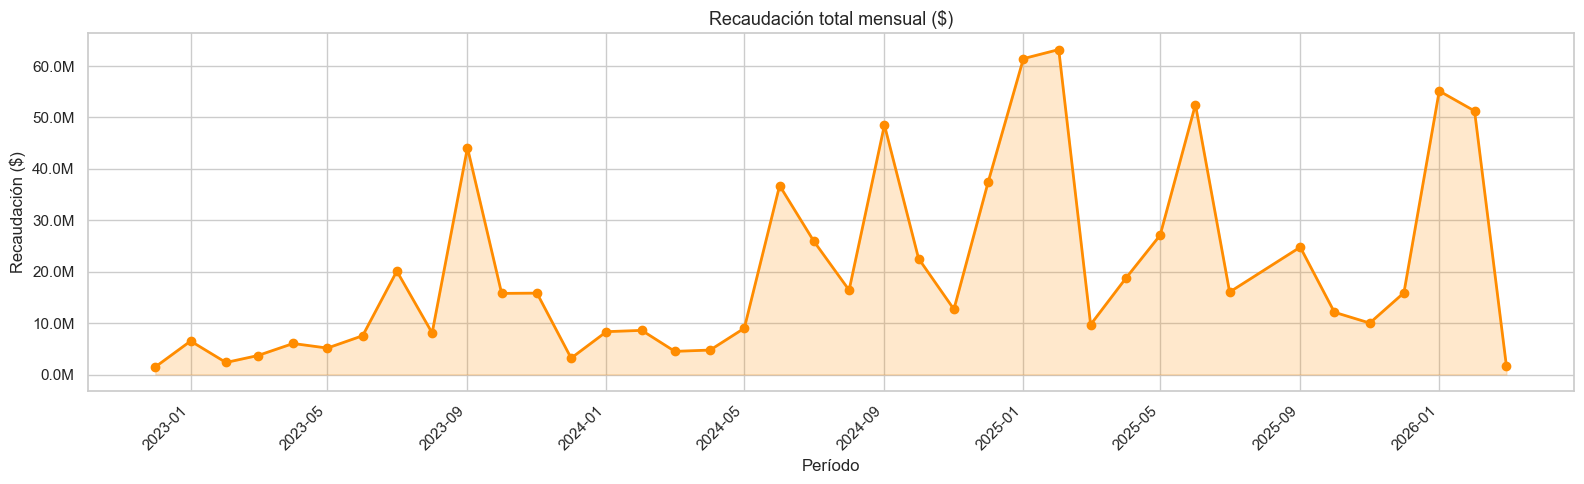

In [22]:
# Recaudación mensual total
recaud_mensual = df.groupby('FECHA_PERIODO')['TOTAL'].sum().reset_index(name='Recaudacion')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(recaud_mensual['FECHA_PERIODO'], recaud_mensual['Recaudacion'],
        marker='o', color='darkorange', linewidth=2)
ax.fill_between(recaud_mensual['FECHA_PERIODO'], recaud_mensual['Recaudacion'],
                alpha=0.2, color='darkorange')
ax.set_title('Recaudación total mensual ($)', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Recaudación ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

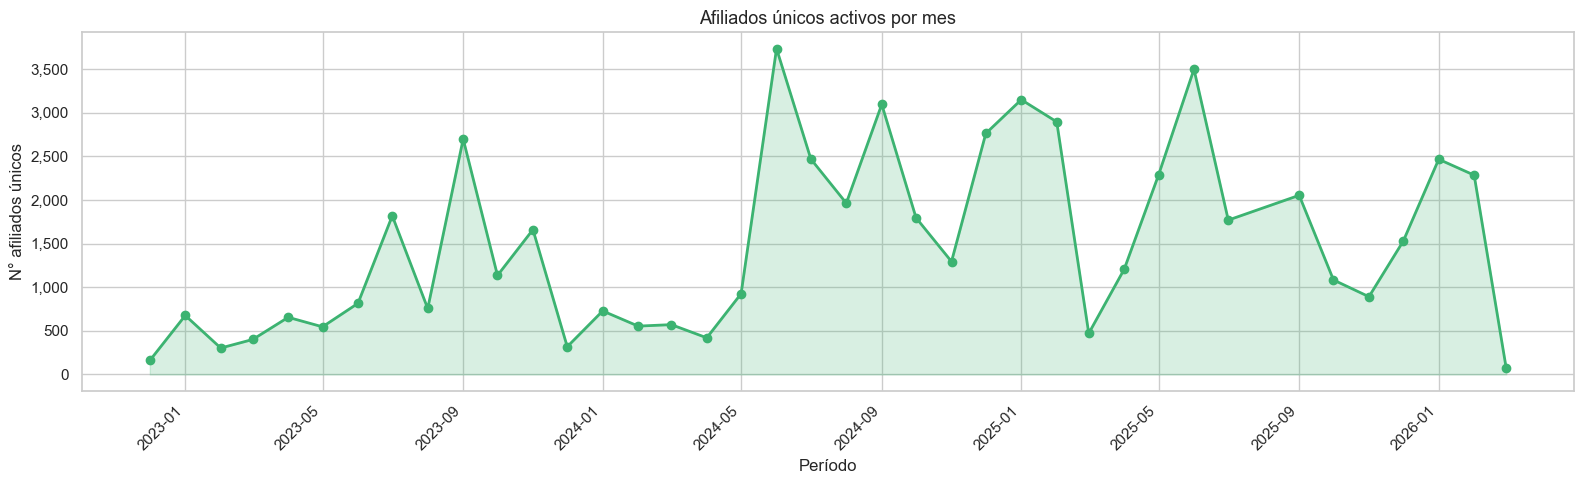

In [23]:
# Afiliados únicos activos por mes
afi_mensual = df.groupby('FECHA_PERIODO')['ID_AFI'].nunique().reset_index(name='Afiliados_Unicos')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(afi_mensual['FECHA_PERIODO'], afi_mensual['Afiliados_Unicos'],
        marker='o', color='mediumseagreen', linewidth=2)
ax.fill_between(afi_mensual['FECHA_PERIODO'], afi_mensual['Afiliados_Unicos'],
                alpha=0.2, color='mediumseagreen')
ax.set_title('Afiliados únicos activos por mes', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('N° afiliados únicos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

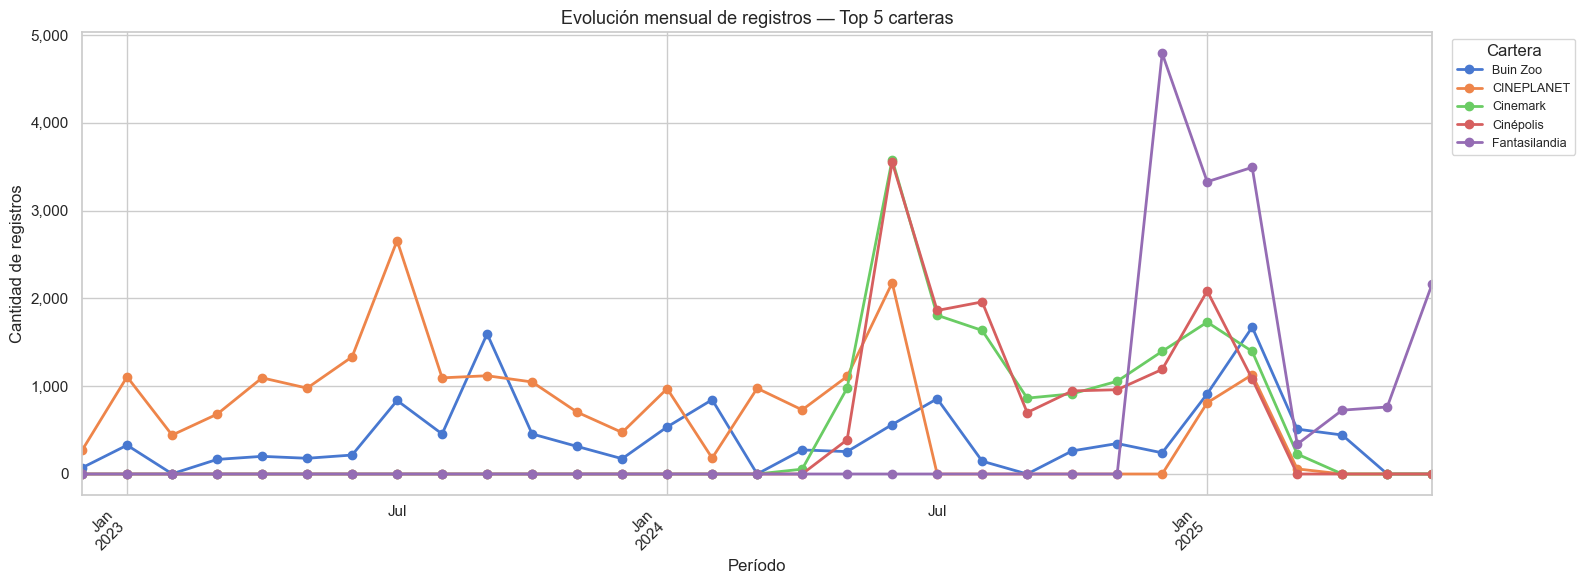

In [24]:
# Evolución temporal por cartera (top 5 carteras más frecuentes)
top5_carteras = df['NTIPO_CARTERA'].value_counts().head(5).index.tolist()
df_top5 = df[df['NTIPO_CARTERA'].isin(top5_carteras)]

pivot_cartera = df_top5.groupby(['FECHA_PERIODO', 'NTIPO_CARTERA']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
pivot_cartera.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Evolución mensual de registros — Top 5 carteras', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Cantidad de registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Cartera', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Análisis de Lag entre Transacción y Pago

In [25]:
df['DIAS_LAG_PAGO'] = (df['FECHA_PAGO'] - df['FEC_TRANSAC']).dt.days

print('=== Días entre FEC_TRANSAC y FECHA_PAGO ===')
print(df['DIAS_LAG_PAGO'].describe().to_string())
print(f'\nRegistros con FECHA_PAGO < FEC_TRANSAC : {(df["DIAS_LAG_PAGO"] < 0).sum():,}')
print(f'Registros con FECHA_PAGO == FEC_TRANSAC: {(df["DIAS_LAG_PAGO"] == 0).sum():,}')
print(f'Registros con lag > 30 días            : {(df["DIAS_LAG_PAGO"] > 30).sum():,}')

=== Días entre FEC_TRANSAC y FECHA_PAGO ===
count   171,933.0000
mean         -0.0008
std           0.0283
min          -1.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           0.0000

Registros con FECHA_PAGO < FEC_TRANSAC : 138
Registros con FECHA_PAGO == FEC_TRANSAC: 171,795
Registros con lag > 30 días            : 0


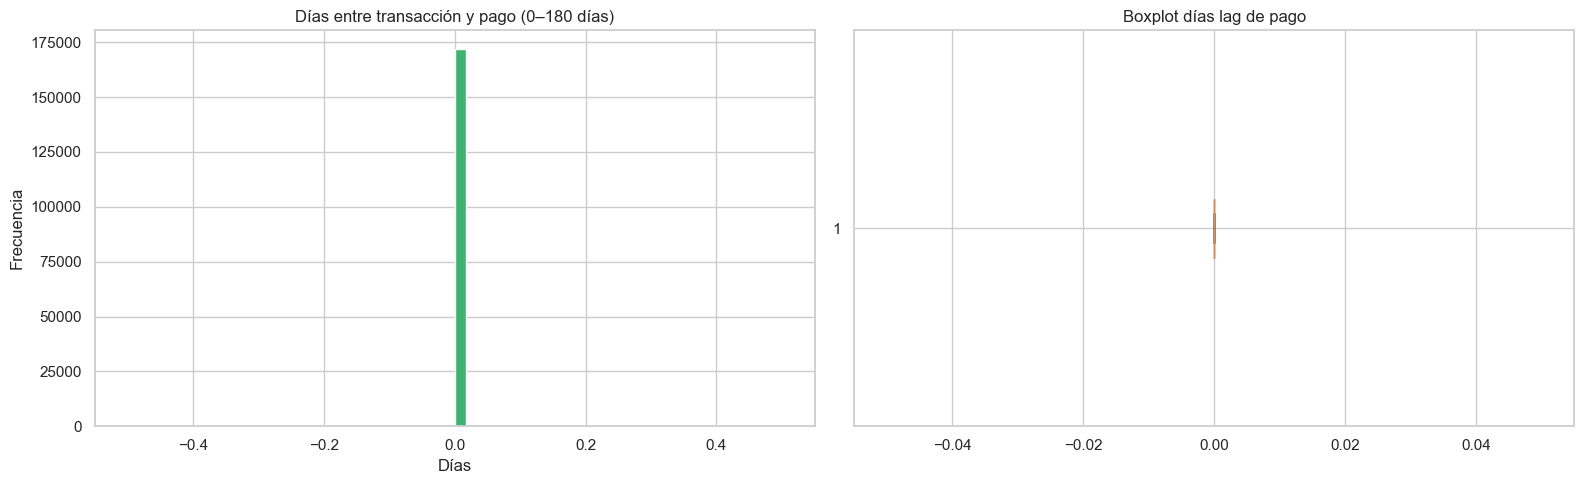


=== Lag de pago por cartera ===


,Promedio,Mediana,Máximo
NTIPO_CARTERA,,,
Buin Zoo,-0.0000,0.0000,0
Buin Zoo Agosto 2025,-0.0000,0.0000,0
Buin Zoo Febrero 2026,0.0000,0.0000,0
CINEPLANET,-0.0000,0.0000,0
Campana Cineplanet Sep2024,0.0000,0.0000,0
Campaña Cineplanet,-0.0000,0.0000,0
Campaña BuinZoo,-0.0000,0.0000,0
Cine Hoyts,-0.0000,0.0000,0
Cinemark,-0.0000,0.0000,0


In [26]:
lag_valido = df.loc[(df['DIAS_LAG_PAGO'] >= 0) & (df['DIAS_LAG_PAGO'] <= 180), 'DIAS_LAG_PAGO']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(lag_valido, bins=60, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Días entre transacción y pago (0–180 días)', fontsize=12)
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(lag_valido, vert=False, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[1].set_title('Boxplot días lag de pago')

plt.tight_layout()
plt.show()

# Lag promedio por cartera
lag_por_cartera = df.groupby('NTIPO_CARTERA')['DIAS_LAG_PAGO'].agg(['mean', 'median', 'max']).round(2)
lag_por_cartera.columns = ['Promedio', 'Mediana', 'Máximo']
print('\n=== Lag de pago por cartera ===')
display(lag_por_cartera.sort_values('Promedio', ascending=False))

## 11. Análisis de Afiliados

In [27]:
n_afiliados = df['ID_AFI'].nunique()
print(f'Afiliados únicos (pseudonimizados): {n_afiliados:,}')
print(f'Promedio de registros por afiliado: {len(df)/n_afiliados:.2f}')

recuento_afi = df['ID_AFI'].value_counts()
print(f'\nDistribución de registros por afiliado:')
print(recuento_afi.describe().to_string())

Afiliados únicos (pseudonimizados): 27,474
Promedio de registros por afiliado: 6.26

Distribución de registros por afiliado:
count   27,474.0000
mean         6.2580
std          6.5721
min          1.0000
25%          2.0000
50%          4.0000
75%          7.0000
max        112.0000


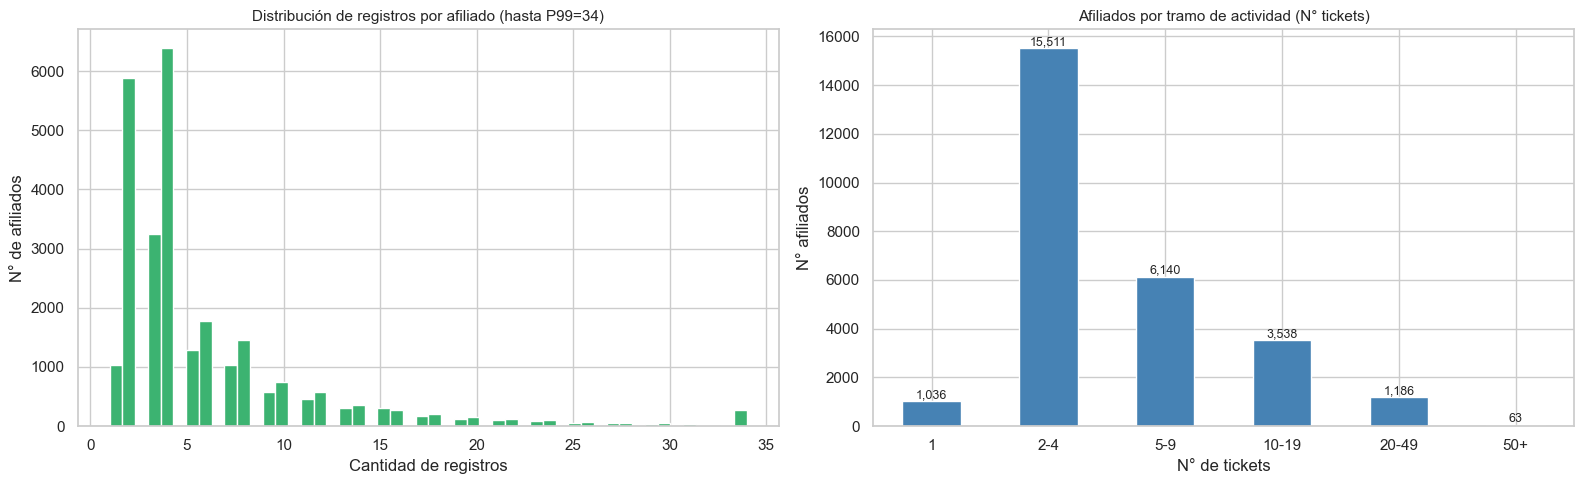

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma registros por afiliado (hasta P99)
p99 = recuento_afi.quantile(0.99)
recuento_afi.clip(upper=p99).hist(bins=50, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title(f'Distribución de registros por afiliado (hasta P99={p99:.0f})', fontsize=11)
axes[0].set_xlabel('Cantidad de registros')
axes[0].set_ylabel('N° de afiliados')

# Afiliados por tramo de actividad
tramos    = [1, 2, 5, 10, 20, 50, np.inf]
etiquetas = ['1', '2-4', '5-9', '10-19', '20-49', '50+']
tramo_counts = pd.cut(recuento_afi, bins=tramos, labels=etiquetas, right=False).value_counts().sort_index()
tramo_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Afiliados por tramo de actividad (N° tickets)', fontsize=11)
axes[1].set_xlabel('N° de tickets')
axes[1].set_ylabel('N° afiliados')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
plt.sca(axes[1]); plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== Gasto total por afiliado ===
count    27,474.0000
mean     28,931.7096
std      26,998.7034
min       1,800.0000
25%      10,000.0000
50%      20,000.0000
75%      39,345.0000
max     529,590.0000


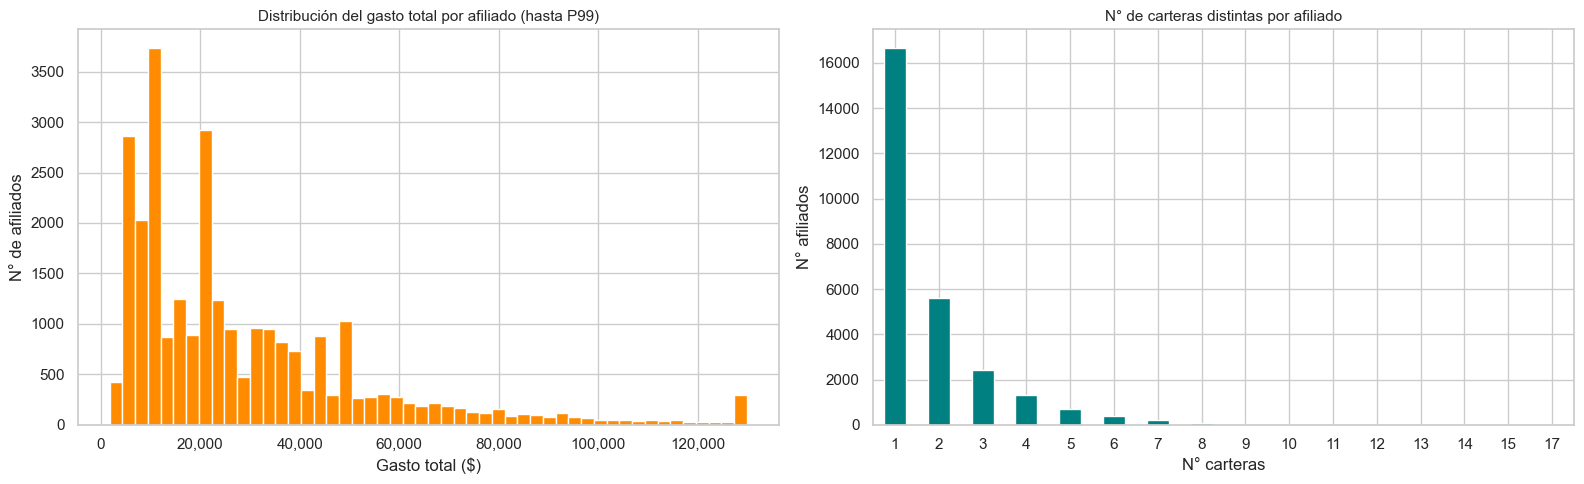

In [29]:
# Gasto total por afiliado
gasto_afi = df.groupby('ID_AFI')['TOTAL'].sum().astype(float)

print('=== Gasto total por afiliado ===')
print(gasto_afi.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

gasto_afi.clip(upper=gasto_afi.quantile(0.99)).hist(
    bins=50, ax=axes[0], color='darkorange', edgecolor='white'
)
axes[0].set_title('Distribución del gasto total por afiliado (hasta P99)', fontsize=11)
axes[0].set_xlabel('Gasto total ($)')
axes[0].set_ylabel('N° de afiliados')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Cantidad de carteras distintas por afiliado
carteras_afi = df.groupby('ID_AFI')['NTIPO_CARTERA'].nunique()
carteras_afi.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('N° de carteras distintas por afiliado', fontsize=11)
axes[1].set_xlabel('N° carteras')
axes[1].set_ylabel('N° afiliados')
plt.sca(axes[1]); plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

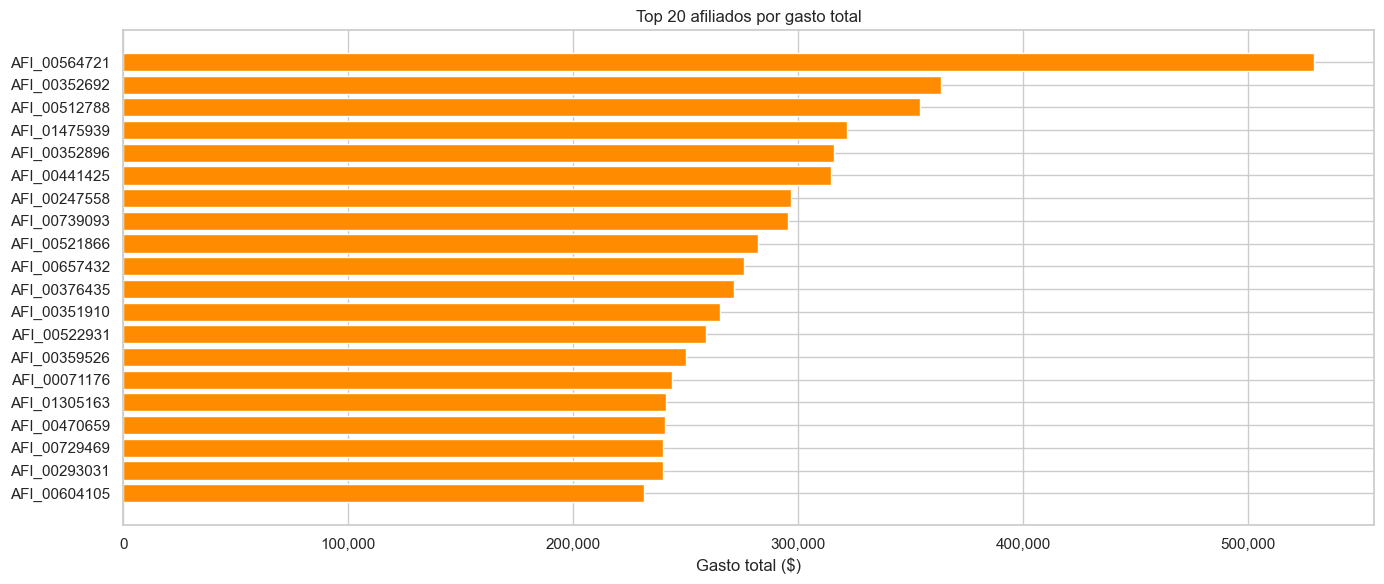

In [30]:
# Top 20 afiliados por gasto total
top20_afi_gasto = gasto_afi.nlargest(20).reset_index()
top20_afi_gasto.columns = ['ID_AFI', 'Gasto_Total']

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top20_afi_gasto['ID_AFI'], top20_afi_gasto['Gasto_Total'], color='darkorange', edgecolor='white')
ax.set_title('Top 20 afiliados por gasto total', fontsize=12)
ax.set_xlabel('Gasto total ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Análisis de Carteras por Período — Heatmap

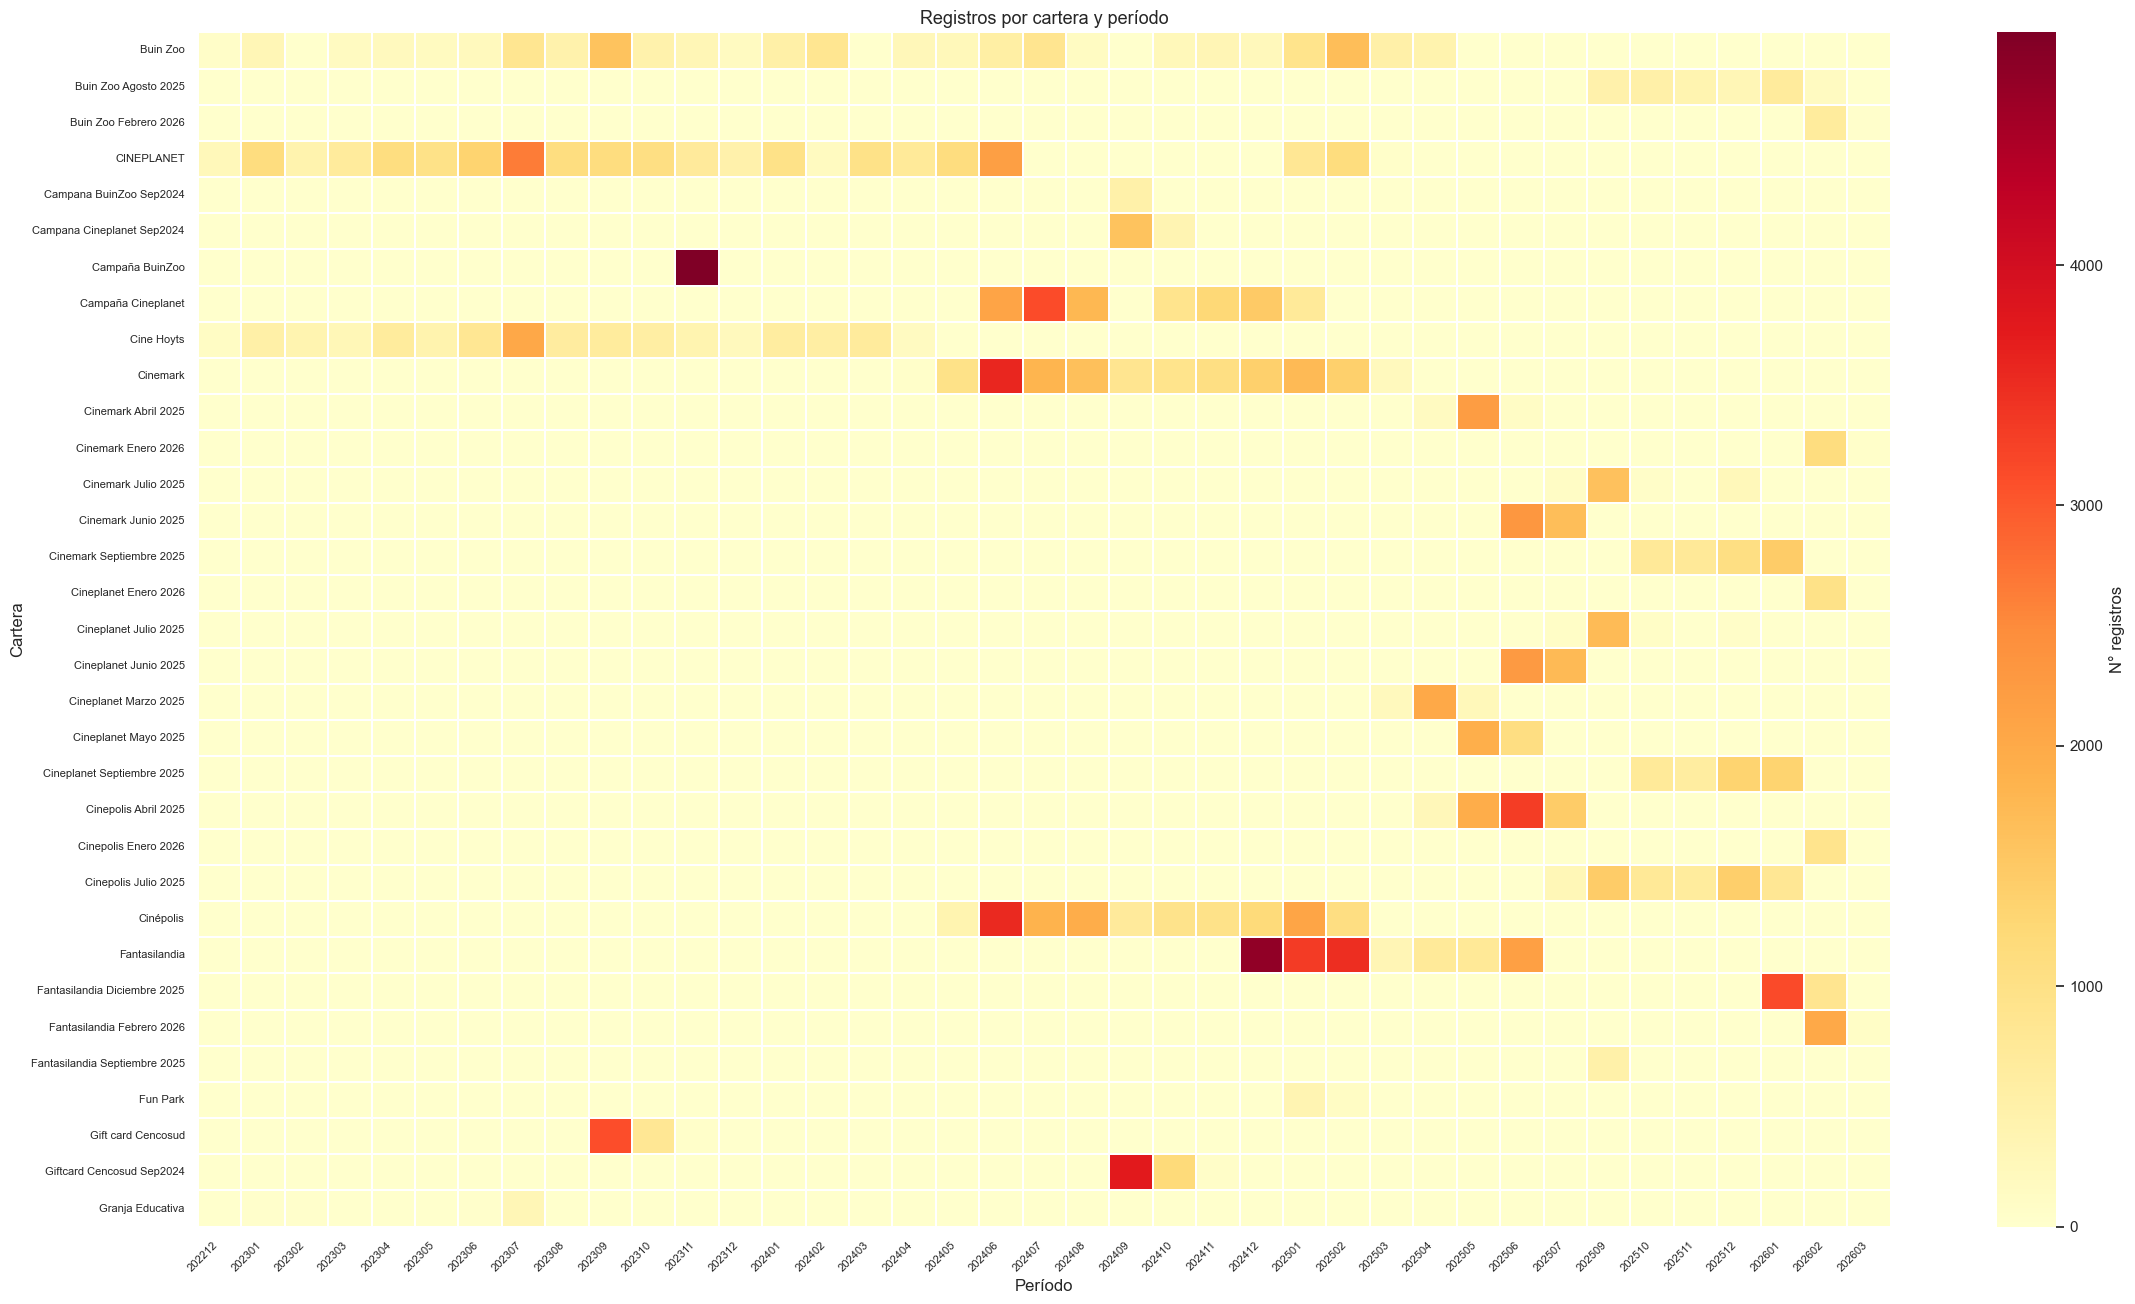

In [31]:
# Heatmap: registros por cartera y período
pivot_heat = df.pivot_table(
    index='NTIPO_CARTERA',
    columns='PERIODO',
    values='TOTAL',
    aggfunc='count',
    fill_value=0
)

# Filtrar carteras con al menos 100 registros totales
pivot_heat = pivot_heat[pivot_heat.sum(axis=1) >= 100].astype(int)

anotar = pivot_heat.shape[0] * pivot_heat.shape[1] < 300
fig, ax = plt.subplots(figsize=(max(16, pivot_heat.shape[1] * 0.6), max(8, pivot_heat.shape[0] * 0.4)))
sns.heatmap(
    pivot_heat, cmap='YlOrRd', linewidths=0.3, ax=ax,
    annot=anotar, fmt=',d',
    cbar_kws={'label': 'N° registros'}
)
ax.set_title('Registros por cartera y período', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Cartera')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 13. Detección de Duplicados

In [32]:
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Duplicados por combinaciones clave de negocio
claves_negocio = [
    ['ID_AFI', 'PERIODO', 'TIPO_CARTERA'],
    ['ID_AFI', 'PERIODO', 'NTIPO_CARTERA'],
    ['ID_AFI', 'FEC_TRANSAC', 'TIPO_CARTERA'],
    ['ID_AFI', 'FEC_TRANSAC', 'TIPO_CARTERA', 'TOTAL'],
]

for clave in claves_negocio:
    cols_existentes = [c for c in clave if c in df.columns]
    dups = df.duplicated(subset=cols_existentes).sum()
    print(f'Duplicados por {cols_existentes}: {dups:,} ({dups/len(df)*100:.4f}%)')

print(f'\nEjemplo de registros potencialmente duplicados (AFI + PERIODO + TIPO_CARTERA):')
clave_dup = ['ID_AFI', 'PERIODO', 'TIPO_CARTERA']
dups_mask = df.duplicated(subset=clave_dup, keep=False)
display(df[dups_mask].sort_values(clave_dup).head(10))

Filas completamente duplicadas: 108,754 (63.2537%)
Duplicados por ['ID_AFI', 'PERIODO', 'TIPO_CARTERA']: 111,216 (64.6857%)
Duplicados por ['ID_AFI', 'PERIODO', 'NTIPO_CARTERA']: 111,224 (64.6903%)
Duplicados por ['ID_AFI', 'FEC_TRANSAC', 'TIPO_CARTERA']: 108,755 (63.2543%)
Duplicados por ['ID_AFI', 'FEC_TRANSAC', 'TIPO_CARTERA', 'TOTAL']: 108,755 (63.2543%)

Ejemplo de registros potencialmente duplicados (AFI + PERIODO + TIPO_CARTERA):


,PERIODO,TOTAL,TIPO_CARTERA,NTIPO_CARTERA,FEC_TRANSAC,FECHA_PAGO,ID_AFI,FECHA_PERIODO,DIAS_LAG_PAGO
7535,202309,10000,115,Gift card Cencosud,2023-09-06,2023-09-06,AFI_00000001,2023-09-01,0
7536,202309,10000,115,Gift card Cencosud,2023-09-06,2023-09-06,AFI_00000001,2023-09-01,0
69612,202502,10990,124,Fantasilandia,2025-02-17,2025-02-17,AFI_00000001,2025-02-01,0
69613,202502,10990,124,Fantasilandia,2025-02-17,2025-02-17,AFI_00000001,2025-02-01,0
9434,202309,10000,115,Gift card Cencosud,2023-09-07,2023-09-07,AFI_00000127,2023-09-01,0
9435,202309,10000,115,Gift card Cencosud,2023-09-07,2023-09-07,AFI_00000127,2023-09-01,0
42724,202402,7500,101,Buin Zoo,2024-02-09,2024-02-09,AFI_00000388,2024-02-01,0
42725,202402,7500,101,Buin Zoo,2024-02-09,2024-02-09,AFI_00000388,2024-02-01,0
42726,202402,7500,101,Buin Zoo,2024-02-09,2024-02-09,AFI_00000388,2024-02-01,0
42727,202402,7500,101,Buin Zoo,2024-02-09,2024-02-09,AFI_00000388,2024-02-01,0


## 14. Detección de Outliers

In [33]:
def detectar_outliers_iqr(serie, nombre):
    Q1    = serie.quantile(0.25)
    Q3    = serie.quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna'        : nombre,
        'Q1'             : Q1,
        'Q3'             : Q3,
        'IQR'            : IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° outliers'    : len(outliers),
        '% outliers'     : round(len(outliers) / len(serie) * 100, 2)
    }

cols_outlier = [c for c in ['TOTAL', 'DIAS_LAG_PAGO'] if c in df.columns]
resumen_outliers = pd.DataFrame([detectar_outliers_iqr(df[c].dropna(), c) for c in cols_outlier])

print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
TOTAL,"2,500.00","5,000.00","2,500.00","-1,250.00","8,750.00","29,658.00",17.25
DIAS_LAG_PAGO,0.00,0.00,0.00,0.00,0.00,138.00,0.08


## 15. Análisis de Correlaciones

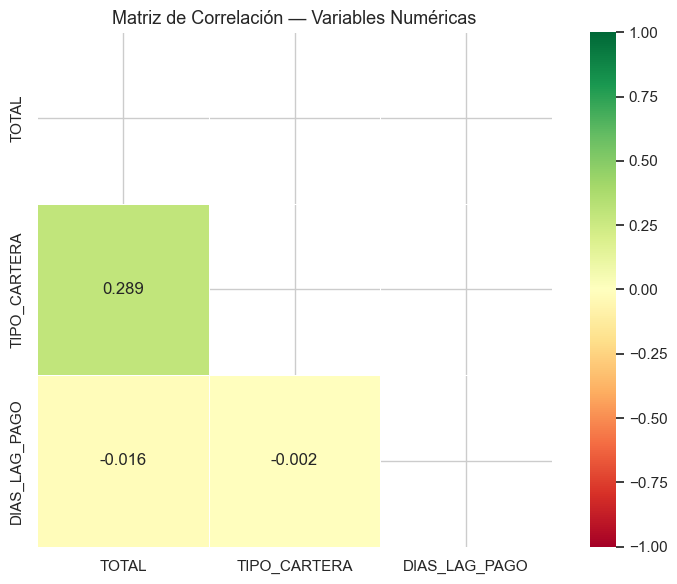

In [34]:
cols_corr = [c for c in ['TOTAL', 'TIPO_CARTERA', 'DIAS_LAG_PAGO'] if c in df.columns]

if len(cols_corr) > 1:
    corr_matrix = df[cols_corr].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13)
    plt.tight_layout()
    plt.show()

## 16. Resumen Ejecutivo

In [35]:
print('=' * 65)
print('   RESUMEN EJECUTIVO — EDA VENTA TICKET MENSUAL BNF')
print('=' * 65)

print(f'\n[VOLUMEN]')
print(f'  Total registros      : {len(df):,}')
print(f'  Total columnas       : {df.shape[1]}')
print(f'  Rango temporal       : {df["PERIODO"].min()} → {df["PERIODO"].max()}')
print(f'  Períodos únicos      : {df["PERIODO"].nunique()}')

print(f'\n[AFILIADOS]')
print(f'  Afiliados únicos     : {df["ID_AFI"].nunique():,}')
print(f'  Promedio tix/afiliado: {len(df)/df["ID_AFI"].nunique():.2f}')

print(f'\n[CARTERAS]')
print(f'  Carteras únicas      : {df["NTIPO_CARTERA"].nunique()}')
top_cart = df['NTIPO_CARTERA'].value_counts().index[0]
pct_cart = df['NTIPO_CARTERA'].value_counts().iloc[0] / len(df) * 100
print(f'  Cartera más freq.    : "{top_cart}" ({pct_cart:.1f}%)')

print(f'\n[MONTOS]')
print(f'  Recaudación total    : ${df["TOTAL"].sum():>20,.0f}')
print(f'  Ticket promedio      : ${df["TOTAL"].mean():>20,.2f}')
print(f'  Ticket mediana       : ${df["TOTAL"].median():>20,.2f}')
print(f'  Valores únicos TOTAL : {df["TOTAL"].nunique()}')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos = df.isnull().sum().sum() / (len(df) * df.shape[1]) * 100
print(f'  Tasa de nulidad      : {pct_nulos:.4f}%')
print(f'  Duplicados exactos   : {df.duplicated().sum():,}')

if 'DIAS_LAG_PAGO' in df.columns:
    print(f'\n[PROCESAMIENTO]')
    print(f'  Mediana lag transac.→pago: {df["DIAS_LAG_PAGO"].median():.0f} días')
    mismo_dia = (df['DIAS_LAG_PAGO'] == 0).sum()
    print(f'  Pagos mismo día          : {mismo_dia:,} ({mismo_dia/len(df)*100:.1f}%)')

print('\n' + '=' * 65)

   RESUMEN EJECUTIVO — EDA VENTA TICKET MENSUAL BNF

[VOLUMEN]
  Total registros      : 171,933
  Total columnas       : 9
  Rango temporal       : 202212 → 202603
  Períodos únicos      : 39

[AFILIADOS]
  Afiliados únicos     : 27,474
  Promedio tix/afiliado: 6.26

[CARTERAS]
  Carteras únicas      : 33
  Cartera más freq.    : "CINEPLANET" (12.3%)

[MONTOS]
  Recaudación total    : $         794,869,790
  Ticket promedio      : $            4,623.14
  Ticket mediana       : $            3,000.00
  Valores únicos TOTAL : 21

[CALIDAD DE DATOS]
  Tasa de nulidad      : 0.0000%
  Duplicados exactos   : 108,754

[PROCESAMIENTO]
  Mediana lag transac.→pago: 0 días
  Pagos mismo día          : 171,795 (99.9%)

